# 1. Predict trên tập train

In [1]:
from ultralytics import YOLO

# 1. Load model đã train của bạn
model = YOLO('/Users/mac/Detect_Drill_Bit/Models_After_Handle_Data/yolov12_after_aug/results/runs/detect/train/weights/best.pt')

# 2. Chạy validation và xuất JSON
metrics = model.val(
    data='/Users/mac/Detect_Drill_Bit/data_convert_yolo_format/data.yaml',
    split='train',
    save_json=True,
    device="mps"
)

Ultralytics 8.4.103 🚀 Python-3.11.9 torch-2.13.0 MPS (Apple M4)
YOLOv12n summary (fused): 159 layers, 2,557,703 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 83.8±10.2 MB/s, size: 11.9 KB)
val: Scanning /Users/mac/Detect_Drill_Bit/data_convert_yolo_format/train/labels.cache... 3521 images, 843 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4364/4364 554.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 273/273 3.4it/s 1:210.3sss
                   all       4364       5360      0.908        0.9      0.954      0.681
                Broken        747        747      0.977      0.997      0.994      0.812
               Chipped        927       1134      0.923      0.905      0.962      0.638
             Scratched       1278       1367      0.894      0.806      0.924      0.603
           Severe_Rust        831       1205      0.857      0.836       0.92      0.659
              Tip

# 2. Dùng TIDE để đánh giá lỗi

Fixed 60308 predictions, saved to /Users/mac/Detect_Drill_Bit/Hard_Exampling/val-4/predictions_fixed.json
-- predictions_fixed --

bbox AP @ 50: 93.63

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.12     0.97     0.10     0.52     1.14     2.03  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       3.79       2.21  



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a

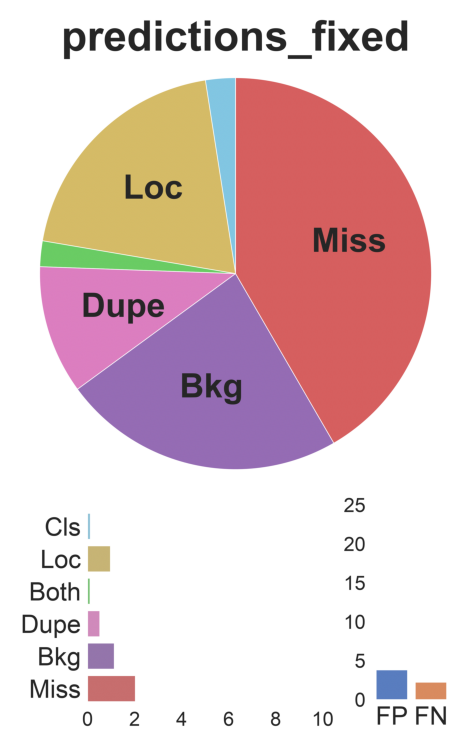

In [228]:
import json
from tidecv import TIDE, Data, datasets

def load_coco_bbox_only(json_path, name="gt"):
    with open(json_path, 'r') as f:
        coco_json = json.load(f)
    
    data = Data(name)
    
    # Build mapping filename -> image_id
    filename_to_id = {img['file_name']: img['id'] for img in coco_json.get('images', [])}
    
    # 1. Nạp danh sách các Class
    for cat in coco_json.get('categories', []):
        data.add_class(cat['id'], cat['name'])
        
    # 2. Nạp Ground Truth Annotations
    for ann in coco_json.get('annotations', []):
        image_id = ann['image_id']
        category_id = ann['category_id']
        bbox = ann['bbox'] # [x, y, width, height]
        
        if ann.get('iscrowd', 0):
            data.add_ignore_region(image_id, category_id, bbox)
        else:
            data.add_ground_truth(image_id, category_id, bbox)
            
    return data, filename_to_id

def fix_predictions_image_id(pred_json_path, filename_to_id, output_path):
    """Fix predictions.json: replace filename with numeric image_id"""
    with open(pred_json_path, 'r') as f:
        pred_data = json.load(f)
    
    fixed_preds = []
    for pred in pred_data:
        filename = pred['file_name']
        image_id = filename_to_id.get(filename)
        
        if image_id is not None:
            pred_copy = pred.copy()
            pred_copy['image_id'] = image_id
            # Remove file_name since COCO format uses image_id
            del pred_copy['file_name']
            fixed_preds.append(pred_copy)
    
    with open(output_path, 'w') as f:
        json.dump(fixed_preds, f)
    
    print(f"Fixed {len(fixed_preds)} predictions, saved to {output_path}")
    return len(fixed_preds)

# --- THỰC THI ĐÁNH GIÁ ---
tide = TIDE()

# 1. Load Ground Truth với mapping
gt, filename_to_id = load_coco_bbox_only('/Users/mac/Detect_Drill_Bit/clean-data/train/_annotations.coco.json')

# 2. Fix predictions.json: map filename -> numeric image_id
fixed_pred_path = '/Users/mac/Detect_Drill_Bit/Hard_Exampling/val-4/predictions_fixed.json'
fix_predictions_image_id(
    '/Users/mac/Detect_Drill_Bit/Hard_Exampling/val-4/predictions.json',
    filename_to_id,
    fixed_pred_path
)

# 3. Load Predictions với COCOResult (sau khi fix)
pred = datasets.COCOResult(fixed_pred_path)

# 4. Đánh giá và in báo cáo
tide.evaluate(gt, pred, mode=TIDE.BOX)
tide.summarize()
tide.plot()

# 3. Lưu các ảnh bị lỗi

### 1. đọc ground và predict

In [229]:
import json
from collections import defaultdict

class COCOLoader:
    def __init__(self, json_gr, json_predict, conf_threshold=0.25):
        self.json_gr = json_gr
        self.images = {}
        self.categories = {}
        self.json_predict = json_predict
        self.conf_threshold = conf_threshold
        self.ground_truth_path = defaultdict(list)
        self.predict_path = defaultdict(list)
    
    def load_ground_truth(self):
        with open(self.json_gr, "r") as f:
            coco = json.load(f)
        
        for image in coco["images"]:
            self.images[image["id"]] = {
                "file_name": image["file_name"],
                "height": image["height"],
                "width": image["width"]
            }
        for category in coco["categories"]:
            self.categories[category["id"]] = category["name"]
        
        for annotation in coco["annotations"]:
            self.ground_truth_path[annotation["image_id"]].append({
                "id": annotation["id"],
                "category": annotation["category_id"],
                "bbox": annotation["bbox"],
                "iscrowd": annotation["iscrowd"]
            })
        return self.ground_truth_path

    def load_prediction(self):
        with open(self.json_predict, "r") as f:
            coco = json.load(f)
        
        for prediction in coco:
            if prediction.get("score", 1.0) < self.conf_threshold:
                continue
            image_id = prediction["image_id"]
            self.predict_path[image_id].append({
                "category": prediction["category_id"],
                "bbox": prediction["bbox"],
                "score": prediction["score"]
            })
        return self.predict_path

    
    def load(self):
        self.load_ground_truth()
        self.load_prediction()
        return {
            "images": self.images,
            "categories": self.categories,
            "ground_truth": self.ground_truth_path,
            "prediction": self.predict_path
        }

In [230]:
test = COCOLoader("/Users/mac/Detect_Drill_Bit/clean-data/train/_annotations.coco.json", "/Users/mac/Detect_Drill_Bit/Hard_Exampling/val-4/predictions_fixed.json").load()

In [231]:
print(test["ground_truth"][150])

[{'id': 108, 'category': 2, 'bbox': [196, 306, 19, 49], 'iscrowd': 0}, {'id': 109, 'category': 2, 'bbox': [265, 1, 19, 53], 'iscrowd': 0}]


In [232]:
print(test["prediction"][150])

[{'category': 2, 'bbox': [194.173, 304.838, 22.844, 46.654], 'score': 0.70574}, {'category': 2, 'bbox': [277.651, 335.957, 16.542, 42.953], 'score': 0.55168}, {'category': 2, 'bbox': [264.03, 0.949, 20.687, 51.712], 'score': 0.49745}]


In [233]:
print(test["categories"])

{0: 'drill', 1: 'Broken', 2: 'Chipped', 3: 'Scratched', 4: 'Severe_Rust', 5: 'Tip_Wear'}


### 2. tính toán iou để kiểm tra xem matching bao nhiêu

In [234]:
import numpy as np
def coco_to_xyxy(box):
    x_min , y_min, w, h = box
    return np.array([x_min, y_min, x_min + w, y_min + h], dtype=float)

def compute_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - inter
    if union == 0:
        return 0.0
    return inter / union

def calculate_iou_matrix(gt_boxes, pred_boxes):
    mat = np.zeros((len(gt_boxes), len(pred_boxes)))

    for i, g in enumerate(gt_boxes):
        for j, p in enumerate(pred_boxes):
            mat[i, j] = compute_iou(
                coco_to_xyxy(g),
                coco_to_xyxy(p)
            )
    return mat

In [235]:
gt=[100,100,50,50]

pred=[105,105,50,50]

print(compute_iou(
    coco_to_xyxy(gt),
    coco_to_xyxy(pred)
))

0.680672268907563


In [236]:
class Matcher:
    def __init__(self, iou_threshold=0.1):
        self.iou_threshold = iou_threshold
    
    def match(self, gt_objects, predict_objects):
        if not gt_objects or not predict_objects:
            return [], list(range(len(gt_objects))), list(range(len(predict_objects)))
        
        gt_boxes = [g["bbox"] for g in gt_objects]
        predict_boxes = [g["bbox"] for g in predict_objects]

        matrix = calculate_iou_matrix(gt_boxes, predict_boxes)
        matched = []
        used_gt = set()
        used_predict = set()

        while True:
            if matrix.size == 0:
                break
            max_iou = matrix.max()
            if max_iou < self.iou_threshold:
                break

            gt_index, predict_index = np.unravel_index(
                np.argmax(matrix),
                matrix.shape
            )

            matched.append({
                "gt_index": gt_index,
                "predict_index": predict_index,
                "iou": float(max_iou)
            })

            used_gt.add(gt_index)
            used_predict.add(predict_index)
            matrix[gt_index, :] = -1
            matrix[:, predict_index] = -1
        
        unmatched_gt = [
            i
            for i in range(len(gt_objects))
            if i not in used_gt
        ]
        unmatched_predict = [
            i for i in range(len(predict_objects))
            if i not in used_predict
        ]
        return matched, unmatched_gt, unmatched_predict

In [237]:
test = COCOLoader("/Users/mac/Detect_Drill_Bit/clean-data/train/_annotations.coco.json", "/Users/mac/Detect_Drill_Bit/Hard_Exampling/val-4/predictions_fixed.json").load()

In [238]:
print(test["ground_truth"][150])

[{'id': 108, 'category': 2, 'bbox': [196, 306, 19, 49], 'iscrowd': 0}, {'id': 109, 'category': 2, 'bbox': [265, 1, 19, 53], 'iscrowd': 0}]


In [239]:
print(test["prediction"][150])

[{'category': 2, 'bbox': [194.173, 304.838, 22.844, 46.654], 'score': 0.70574}, {'category': 2, 'bbox': [277.651, 335.957, 16.542, 42.953], 'score': 0.55168}, {'category': 2, 'bbox': [264.03, 0.949, 20.687, 51.712], 'score': 0.49745}]


In [240]:
matcher = Matcher(0.5)

matched, un_gt, un_pred = matcher.match(
    test["ground_truth"][150],
    test["prediction"][150]
)

In [241]:
print(matched)

[{'gt_index': np.int64(1), 'predict_index': np.int64(2), 'iou': 0.8962313708209334}, {'gt_index': np.int64(0), 'predict_index': np.int64(0), 'iou': 0.7632778222125691}]


In [242]:
print(un_gt)
print(un_pred)

[]
[1]


In [243]:
print(image_id)

print(len(gt))

print(len(pred))


7775
4
4


### 3. Đánh giá quyết định lỗi gì

In [244]:
class Evaluator:
    def __init__(self, tp_iou=0.5, loc_iou=0.1):
        self.tp_iou = tp_iou
        self.loc_iou = loc_iou
    
    def evaluate(self,
                image_id,
                gt_objects,
                predict_objects,
                matched_pairs,
                unmatched_gt,
                unmatched_predict,
                categories):
        errors = []
        
        for pair in matched_pairs:
            gt = gt_objects[pair["gt_index"]]
            predict = predict_objects[pair["predict_index"]]
            
            gt_name = categories[gt["category"]]
            pred_name = categories[predict["category"]]
            iou = pair["iou"]
            score = predict["score"]
            
            if gt["category"] == predict["category"]:
                if iou > self.tp_iou:
                    error_type = "TP"
                elif iou >= self.loc_iou:
                    error_type = "Localization"
                else:
                    error_type = "FalsePositive"
            else:
                if iou >= self.tp_iou:
                    error_type = "Classification"
                elif iou >= self.loc_iou:
                    error_type = "Both"
                else:
                    error_type = "FalsePositive"
            
            errors.append({
                "image_id": image_id,
                "gt_bbox": gt["bbox"],
                "pred_bbox": predict["bbox"],
                "gt_class": gt_name,
                "pred_class": pred_name,
                "iou": round(iou, 3),
                "score": round(score, 3),
                "type": error_type,
                "gt_index": int(pair["gt_index"]),
                "pred_index": int(pair["predict_index"])
            })

        for idx in unmatched_gt:
            gt = gt_objects[idx]
            errors.append({
                "image_id": image_id,
                "gt_bbox": gt["bbox"],
                "pred_bbox": None,
                "gt_class": categories[gt["category"]],
                "pred_class": None,
                "iou": 0.0,
                "score": 0.0,
                "type": "FalseNegative",
                "gt_index": idx,
                "pred_index": None
            })
        
        return errors

In [245]:
class DuplicateDetector:

    def __init__(self, duplicate_iou=0.5):
        self.duplicate_iou = duplicate_iou

    def detect(self, image_id, gt_objects, pred_objects, unmatched_pred, categories):
        results = []

        for pred_idx in unmatched_pred:
            pred = pred_objects[pred_idx]
            best_iou = 0
            best_gt = None
            best_gt_idx = None

            for gt_idx, gt in enumerate(gt_objects):
                iou = compute_iou(
                    coco_to_xyxy(gt["bbox"]),
                    coco_to_xyxy(pred["bbox"])
                )
                if iou > best_iou:
                    best_iou = iou
                    best_gt = gt
                    best_gt_idx = gt_idx

            if best_iou >= self.duplicate_iou:
                error = "Duplicate"
            else:
                error = "FalsePositive"

            results.append({
                "image_id": image_id,
                "gt_bbox": None if best_gt is None else best_gt["bbox"],
                "pred_bbox": pred["bbox"],
                "gt_class": "" if best_gt is None else categories[best_gt["category"]],
                "pred_class": categories[pred["category"]],
                "iou": round(best_iou, 3),
                "score": round(pred["score"], 3),
                "type": error,
                "gt_index": best_gt_idx,
                "pred_index": pred_idx
            })

        return results

In [246]:
matcher = Matcher(0.1)

evaluator = Evaluator()

duplicate_detector = DuplicateDetector()

all_errors = []

data = COCOLoader("/Users/mac/Detect_Drill_Bit/clean-data/train/_annotations.coco.json", "/Users/mac/Detect_Drill_Bit/Hard_Exampling/val-4/predictions_fixed.json").load()

for image_id in data["images"]:

    gt = data["ground_truth"][image_id]

    pred = data["prediction"][image_id]

    matched, un_gt, un_pred = matcher.match(
        gt,
        pred)

    # Evaluate errors
    result = evaluator.evaluate(
        image_id,
        gt,
        pred,
        matched,
        un_gt,
        un_pred,
        data["categories"]
    )

    all_errors.extend(result)
    
    if un_pred:
        dup_results = duplicate_detector.detect(
            image_id,
            gt,
            pred,
            un_pred,
            data["categories"]
        )
        all_errors.extend(dup_results)

for err in all_errors:
    file_name = data["images"][err["image_id"]]["file_name"]
    err["file_name"] = file_name
    err["image_path"] = f"/Users/mac/Detect_Drill_Bit/data_convert_yolo_format/train/images/{file_name}"

In [247]:
print(all_errors[3000])

{'image_id': 3694, 'gt_bbox': [180, 18, 41, 60], 'pred_bbox': [181.1, 23.799, 38.658, 53.771], 'gt_class': 'Severe_Rust', 'pred_class': 'Severe_Rust', 'iou': 0.845, 'score': 0.889, 'type': 'TP', 'gt_index': 0, 'pred_index': 0, 'file_name': 'S232_Image__2025-11-05__14-29-38_bright_6_crop_5_jpg.rf.92ad3c42528aa242f96eef3cc159f6cc.jpg', 'image_path': '/Users/mac/Detect_Drill_Bit/data_convert_yolo_format/train/images/S232_Image__2025-11-05__14-29-38_bright_6_crop_5_jpg.rf.92ad3c42528aa242f96eef3cc159f6cc.jpg'}


#### 4. Xuất file csv từng loại lỗi

In [248]:
df = pd.DataFrame(all_errors)

COLUMN_ORDER = [
    "image_id", "file_name", "image_path",
    "gt_bbox", "pred_bbox",
    "gt_class", "pred_class",
    "iou", "score", "type",
    "gt_index", "pred_index"
]

df = df[COLUMN_ORDER]

output_dir = "/Users/mac/Detect_Drill_Bit/Hard_Exampling/analysis"
os.makedirs(output_dir, exist_ok=True)
df.to_csv(os.path.join(output_dir, "error_analysis.csv"), index=False)

summary = df.groupby("type").size().reset_index(name="count").sort_values("count", ascending=False)
summary.to_csv(os.path.join(output_dir, "summary.csv"), index=False)

print("Columns:", df.columns.tolist())
print(f"\nSaved {len(df)} rows to error_analysis.csv")
print("\nSummary:")
print(summary.to_string(index=False))
print("\nSample row:")
print(df.iloc[0].to_dict())


Columns: ['image_id', 'file_name', 'image_path', 'gt_bbox', 'pred_bbox', 'gt_class', 'pred_class', 'iou', 'score', 'type', 'gt_index', 'pred_index']

Saved 6379 rows to error_analysis.csv

Summary:
          type  count
            TP   4990
 FalsePositive    689
 FalseNegative    360
     Duplicate    243
  Localization     74
Classification     14
          Both      9

Sample row:
{'image_id': 0, 'file_name': 'S5_than_Image__2025-09-03__14-12-46_bright_2_crop_2_jpg.rf.eb77a22a665de398c1283ec415e0e67f.jpg', 'image_path': '/Users/mac/Detect_Drill_Bit/data_convert_yolo_format/train/images/S5_than_Image__2025-09-03__14-12-46_bright_2_crop_2_jpg.rf.eb77a22a665de398c1283ec415e0e67f.jpg', 'gt_bbox': [189, 173, 38, 155], 'pred_bbox': [189.099, 184.287, 42.04, 149.03], 'gt_class': 'Scratched', 'pred_class': 'Scratched', 'iou': 0.812, 'score': 0.667, 'type': 'TP', 'gt_index': 0.0, 'pred_index': 0.0}


### 5. Visualize

In [251]:
import os
import ast
import cv2
import pandas as pd


class Visualizer:


    def __init__(self,
                 csv_path,
                 image_dir,
                 output_dir="analysis"):

        self.csv_path = csv_path
        self.image_dir = image_dir
        self.output_dir = output_dir

        self.colors = {
            "TP": (0, 255, 0),
            "Localization": (0, 255, 255),
            "Classification": (255, 0, 255),
            "Both": (255, 255, 0),
            "Duplicate": (0, 128, 255),
            "FalsePositive": (0, 0, 255),
            "FalseNegative": (255, 0, 0)
        }

    def _make_dirs(self, df):

        for err in df["type"].unique():
            os.makedirs(
                os.path.join(self.output_dir, err),
                exist_ok=True
            )

    @staticmethod
    def draw_box(img, bbox, color, text):

        if bbox is None:
            return

        x, y, w, h = bbox

        x1 = int(x)
        y1 = int(y)
        x2 = int(x + w)
        y2 = int(y + h)

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        cv2.putText(
            img,
            text,
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2
        )

    def visualize(self):

        df = pd.read_csv(self.csv_path)

        self._make_dirs(df)

        for _, row in df.iterrows():

            # Use image_path directly from CSV instead of joining with image_dir
            img_path = row["image_path"]

            if not os.path.exists(img_path):
                continue

            img = cv2.imread(img_path)

            if img is None:
                continue

            color = self.colors.get(
                row["type"],
                (255, 255, 255)
            )

            # -------------------------
            # GT
            # -------------------------

            gt_bbox = None

            if pd.notna(row["gt_bbox"]):
                gt_bbox = ast.literal_eval(row["gt_bbox"])

                self.draw_box(
                    img,
                    gt_bbox,
                    (0, 255, 0),
                    f'GT:{row["gt_class"]}'
                )

            # -------------------------
            # Prediction
            # -------------------------

            pred_bbox = None

            if pd.notna(row["pred_bbox"]):
                pred_bbox = ast.literal_eval(row["pred_bbox"])

                self.draw_box(
                    img,
                    pred_bbox,
                    (0, 0, 255),
                    f'Pred:{row["pred_class"]}'
                )

            # -------------------------
            # Header
            # -------------------------

            text = (
                f'{row["type"]} | '
                f'IoU:{row["iou"]:.2f} | '
                f'Conf:{row["score"]:.2f}'
            )

            cv2.putText(
                img,
                text,
                (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                color,
                2
            )

            save_path = os.path.join(
                self.output_dir,
                row["type"],
                row["file_name"]
            )

            cv2.imwrite(save_path, img)

        print("Visualization completed.")

In [252]:
vis = Visualizer(
    csv_path="/Users/mac/Detect_Drill_Bit/Hard_Exampling/analysis/error_analysis.csv",
    image_dir="/Users/mac/Detect_Drill_Bit/data_convert_yolo_format/train",
    output_dir="analysis"
)

vis.visualize()

Visualization completed.
